In [1]:
using Unitful 
using Plots
using Measures

gr()

Plots.GRBackend()

In [2]:
using Plots
theme(:vibrant)

## funziona corretta

In [3]:
min_pot =  [0.9986997, 0.9978069, 0.9986706, 1.0009229, 0.9994534, 0.99822, 0.9980831, 0.998217, 0.99594384  ,0.99681985,  0.99802446, 0.99784315,  0.9977653,  0.9981247, 0.99690855]
grid_size = ["default",0.5u"mm", 0.45u"mm", 0.4u"mm", 0.35u"mm", 0.3u"mm", 0.25u"mm", 0.2u"mm", 0.15u"mm",  0.1u"mm", 0.05u"mm", 0.035u"mm", 0.03u"mm", 0.02u"mm",  0.01u"mm"]

15-element Vector{Any}:
  "default"
 0.5 mm
 0.45 mm
 0.4 mm
 0.35 mm
 0.3 mm
 0.25 mm
 0.2 mm
 0.15 mm
 0.1 mm
 0.05 mm
 0.035 mm
 0.03 mm
 0.02 mm
 0.01 mm

In [4]:
grod_wrong = ["0.02 mm"]
min_pot_wrong = [0.69480747]

1-element Vector{Float64}:
 0.69480747

In [5]:
using Statistics
r = min_pot ./ 1  # residui normlaizzati

res = min_pot .- 1              # residui centrati a 0
σ = std(res)                    # deviazione standard
res_σ = res ./ σ                # residui normalizzati in unità di sigma
var_pct = 100 .* (min_pot .- 1)

15-element Vector{Float64}:
 -0.1300300000000032
 -0.2193099999999948
 -0.1329400000000036
  0.09228999999999488
 -0.05465999999999527
 -0.17800000000000038
 -0.19168999999999992
 -0.1782999999999979
 -0.40561599999999753
 -0.3180150000000048
 -0.19755399999999979
 -0.2156849999999988
 -0.2234700000000034
 -0.18753000000000242
 -0.30914499999999956

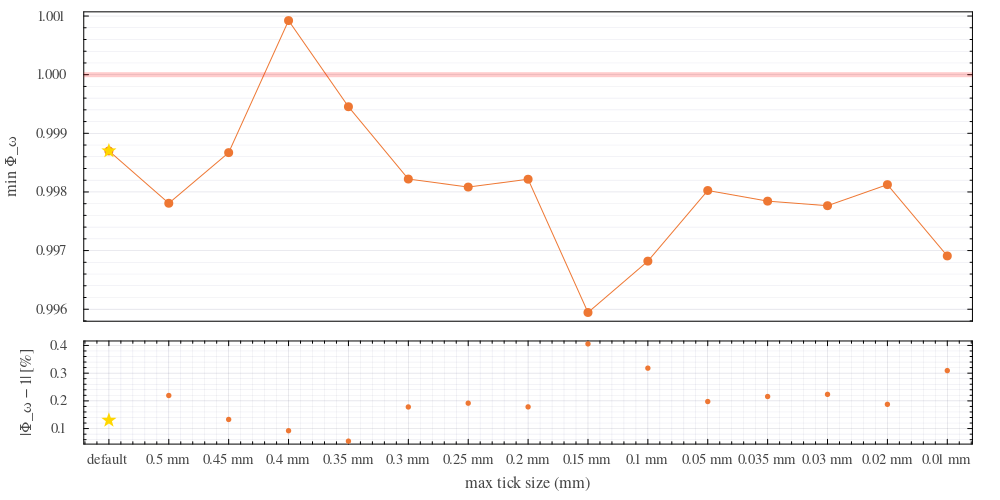

In [6]:
using Plots
using Colors

# Impostazioni "da paper"
default(
    fontfamily = "Times",
    guidefontsize = 10,
    tickfontsize = 9,
    legendfontsize = 9,
    titlefontsize = 10,
    lw = 1,
    ms = 5
)

x = 1:length(grid_size)
labels = string.(grid_size)



# Plot superiore
p1 = plot(
    x, min_pot;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    lw = 1,
    ylabel = "min Φ_ω",
    xticks = false,
    legend = false,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

hline!([1.0], linecolor = :red, lw =5 , alpha = 0.2, label = "Φ_ω = 1")
plot!( [x[1]], [min_pot[1]], seriestype = :scatter, marker = :star, markersize = 8, markercolor = :gold, )
# Plot inferiore
p2 = scatter(
    x,
    abs.(var_pct),
    ylabel = "|Φ_ω − 1| [%]",
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = false,
    markersize = 3,
    top_margin = 0mm,
    bottom_margin = 5mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

plot!( [x[1]], [abs.(var_pct[1])], seriestype = :scatter, marker = :star, markersize = 8, markercolor = :gold, )
plot(
    p1,
    p2,
    layout = grid(
        2, 1,
        heights = [0.75, 0.25],
        hspace = 0mm
    ),
    link = :x, size = (1000, 500)
)


-------

## vector values of potentials